# Replay and Analyze LeRobot Dataset
This notebook loads the dataset recorded by `tele.ipynb` and visualizes the images, states, and actions.

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display, clear_output
import time
from lerobot.datasets.lerobot_dataset import LeRobotDataset

/Users/ningyu/code_before_paper/MyI10Tele/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# 1. Load the dataset
REPO_NAME = 'auboI10'
ROOT = '/Users/ningyu/code_before_paper/MyI10Tele/data'

print(f"Loading dataset from {ROOT}...")
dataset = LeRobotDataset(REPO_NAME, root=ROOT)
print(f"Total episodes: {dataset.num_episodes}")
print(f"Total frames: {dataset.num_frames}")
print(f"Features: {list(dataset.features.keys())}")

Loading dataset from /Users/ningyu/code_before_paper/MyI10Tele/data...
Total episodes: 20
Total frames: 13053
Features: ['observation.image', 'observation.wrist_image', 'observation.state', 'action', 'obj_init', 'timestamp', 'frame_index', 'episode_index', 'index', 'task_index']


Filter: 100%|██████████| 13053/13053 [00:00<00:00, 23830.74 examples/s]


Episode 0 has 649 frames.


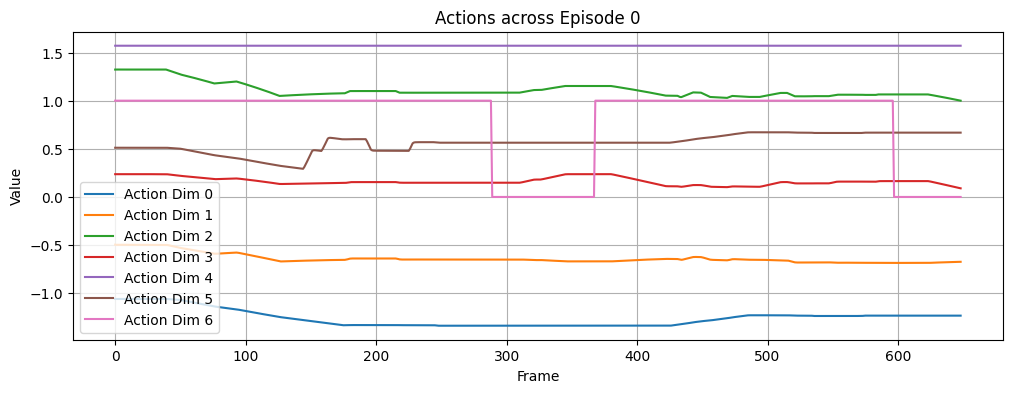

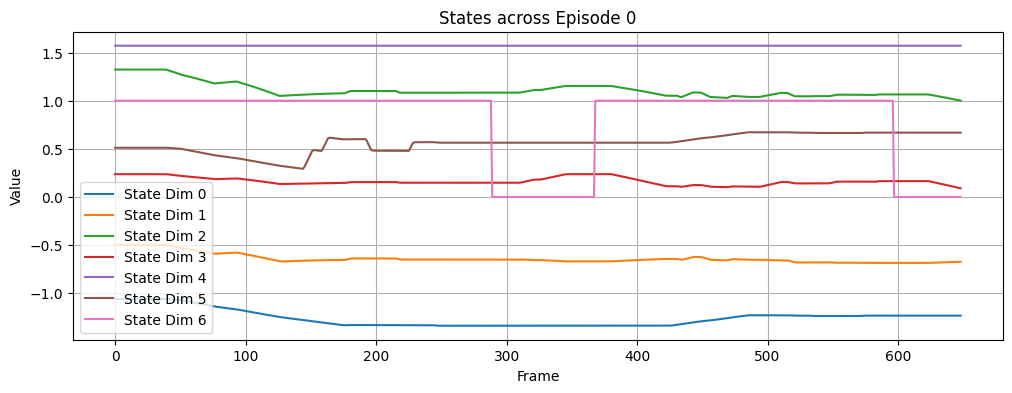

In [3]:
# 2. Analyze the first episode
EPISODE_ID = 0

# We can filter the hf_dataset by episode_index
hf_dataset = dataset.hf_dataset
episode_data = hf_dataset.filter(lambda x: x['episode_index'] == EPISODE_ID)
num_frames_in_ep = len(episode_data)
print(f"Episode {EPISODE_ID} has {num_frames_in_ep} frames.")

# Extract states and actions for plotting
states = np.array(episode_data['observation.state'])
actions = np.array(episode_data['action'])

# Plot Actions over time
plt.figure(figsize=(12, 4))
for i in range(actions.shape[1]):
    plt.plot(actions[:, i], label=f'Action Dim {i}')
plt.title('Actions across Episode 0')
plt.xlabel('Frame')
plt.ylabel('Value')
plt.legend()
plt.grid(True)
plt.show()

# Plot States over time
plt.figure(figsize=(12, 4))
for i in range(states.shape[1]):
    plt.plot(states[:, i], label=f'State Dim {i}')
plt.title('States across Episode 0')
plt.xlabel('Frame')
plt.ylabel('Value')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
# 3. Video Playback of Episode 0
# Note: To play the episode, we will fetch the image tensors and plot them.

import torch
from PIL import Image

FPS = dataset.fps
DELAY = 1.0 / FPS

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 5))

for i in range(num_frames_in_ep):
    # dataset.__getitem__ handles loading images/videos dynamically
    # We need the absolute index in the whole dataset
    abs_idx = episode_data[i]['index']
    if isinstance(abs_idx, torch.Tensor):
        abs_idx = abs_idx.item()
    else:
        abs_idx = int(abs_idx)
    frame_data = dataset[abs_idx]
    
    agent_img = frame_data['observation.image']
    wrist_img = frame_data['observation.wrist_image']
    
    # Convert from torch tensor (C, H, W) to numpy (H, W, C) for matplotlib
    if isinstance(agent_img, torch.Tensor):
        agent_img = agent_img.permute(1, 2, 0).numpy()
    if isinstance(wrist_img, torch.Tensor):
        wrist_img = wrist_img.permute(1, 2, 0).numpy()

    ax1.clear()
    ax2.clear()
    ax1.imshow(agent_img)
    ax1.set_title(f"Agent View - Frame {i}")
    ax1.axis('off')
    
    ax2.imshow(wrist_img)
    ax2.set_title(f"Wrist View - Frame {i}")
    ax2.axis('off')
    
    display(fig)
    clear_output(wait=True)
    time.sleep(DELAY)
    
plt.close(fig)
print("Playback finished!")

KeyboardInterrupt: 

Error in callback <function _draw_all_if_interactive at 0x111a54220> (for post_execute), with arguments args (),kwargs {}:


IndexError: list index out of range

IndexError: list index out of range

<Figure size 1000x500 with 2 Axes>

: 